# Chapter 8: Multi-Agent Systems for Biomedical Research

## Hands-On Jupyter Notebook

This notebook simulates a collaborative multi-agent oncology workflow with planner, specialist, critic, and report agents.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A synthetic set of biomedical research requests
- A role-based multi-agent orchestration table
- Conflict and consensus checks across specialist outputs
- Reviewer-ready summary generation with escalation markers

---

## Section 1: Setup and Imports

This section sets up utilities for simulated multi-agent routing and consensus analysis.

In [7]:
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Environment configured for Chapter 8 multi-agent notebook.')

Environment configured for Chapter 8 multi-agent notebook.


## Section 2: Define Requests and Agent Roles

We define realistic oncology requests and map which specialist agents should participate in each workflow.

In [2]:
requests_df = pd.DataFrame(
    [
        {'request_id': 'm_01', 'goal': 'Summarize EGFR variant evidence for lung case', 'primary_domain': 'genomics', 'risk_level': 'medium'},
        {'request_id': 'm_02', 'goal': 'Draft trial pre-screening shortlist for ERBB2 amplification', 'primary_domain': 'clinical_trials', 'risk_level': 'high'},
        {'request_id': 'm_03', 'goal': 'Synthesize pediatric glioma biomarker literature', 'primary_domain': 'literature', 'risk_level': 'high'},
        {'request_id': 'm_04', 'goal': 'Review cohort-level BRAF prevalence trend', 'primary_domain': 'cohort_analytics', 'risk_level': 'medium'},
    ]
)

agent_roles = pd.DataFrame(
    [
        {'agent': 'planner_agent', 'specialty': 'task_decomposition'},
        {'agent': 'genomics_agent', 'specialty': 'variant_interpretation'},
        {'agent': 'literature_agent', 'specialty': 'evidence_retrieval'},
        {'agent': 'clinical_agent', 'specialty': 'trial_and_clinical_context'},
        {'agent': 'critic_agent', 'specialty': 'safety_and_consistency_checks'},
        {'agent': 'report_agent', 'specialty': 'structured_synthesis'},
    ]
)

display(requests_df)
display(agent_roles)

,request_id,goal,primary_domain,risk_level
0,m_01,Summarize EGFR variant evidence for lung case,genomics,medium
1,m_02,Draft trial pre-screening shortlist for ERBB2 ...,clinical_trials,high
2,m_03,Synthesize pediatric glioma biomarker literature,literature,high
3,m_04,Review cohort-level BRAF prevalence trend,cohort_analytics,medium


,agent,specialty
0,planner_agent,task_decomposition
1,genomics_agent,variant_interpretation
2,literature_agent,evidence_retrieval
3,clinical_agent,trial_and_clinical_context
4,critic_agent,safety_and_consistency_checks
5,report_agent,structured_synthesis


## Section 3: Simulate Multi-Agent Collaboration

We route requests to specialist agents, generate outcome statuses, and run critic checks for conflict or escalation.

In [3]:
domain_to_agents = {
    'genomics': ['planner_agent', 'genomics_agent', 'literature_agent', 'critic_agent', 'report_agent'],
    'clinical_trials': ['planner_agent', 'clinical_agent', 'literature_agent', 'critic_agent', 'report_agent'],
    'literature': ['planner_agent', 'literature_agent', 'genomics_agent', 'critic_agent', 'report_agent'],
    'cohort_analytics': ['planner_agent', 'genomics_agent', 'critic_agent', 'report_agent'],
}

collab_rows = []
for _, req in requests_df.iterrows():
    assigned = domain_to_agents[req['primary_domain']]
    specialist_votes = [
        'supported' if req['risk_level'] == 'medium' else np.random.choice(['supported', 'needs_more_evidence'], p=[0.55, 0.45])
        for _ in assigned if _ in {'genomics_agent', 'literature_agent', 'clinical_agent'}
    ]
    vote_counts = Counter(specialist_votes)
    consensus = 'needs_more_evidence' if vote_counts.get('needs_more_evidence', 0) >= 2 else 'supported'
    requires_review = bool(req['risk_level'] == 'high' or consensus == 'needs_more_evidence')
    collab_rows.append({
        'request_id': req['request_id'],
        'primary_domain': req['primary_domain'],
        'risk_level': req['risk_level'],
        'assigned_agents': assigned,
        'consensus_status': consensus,
        'requires_human_review': requires_review,
        'agent_count': len(assigned),
    })

collab_df = pd.DataFrame(collab_rows)
display(collab_df[['request_id', 'primary_domain', 'risk_level', 'agent_count', 'consensus_status', 'requires_human_review']])

,request_id,primary_domain,risk_level,agent_count,consensus_status,requires_human_review
0,m_01,genomics,medium,5,supported,False
1,m_02,clinical_trials,high,5,supported,True
2,m_03,literature,high,5,needs_more_evidence,True
3,m_04,cohort_analytics,medium,4,supported,False


## Section 4: Collaboration and Safety Metrics

We inspect coordination patterns: agent load, consensus outcomes, and review burden.

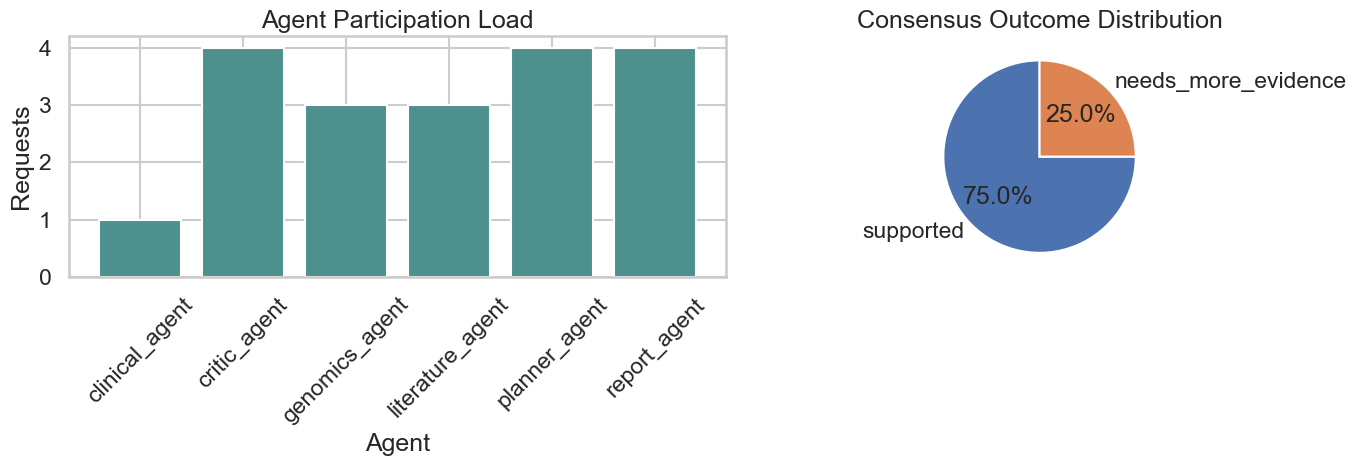

,assigned_agents,requests
0,clinical_agent,1
1,critic_agent,4
2,genomics_agent,3
3,literature_agent,3
4,planner_agent,4
5,report_agent,4


In [4]:
agent_load = collab_df.explode('assigned_agents').groupby('assigned_agents', as_index=False).agg(requests=('request_id', 'count'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(agent_load['assigned_agents'], agent_load['requests'], color='#4D908E')
axes[0].set_title('Agent Participation Load')
axes[0].set_xlabel('Agent')
axes[0].set_ylabel('Requests')
axes[0].tick_params(axis='x', rotation=45)

consensus_counts = collab_df['consensus_status'].value_counts()
axes[1].pie(consensus_counts.values, labels=consensus_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Consensus Outcome Distribution')

plt.tight_layout()
plt.show()

display(agent_load)

## Section 5: Exercises

### Exercise 1: Coordination Integrity Check

Verify that each workflow includes planner, critic, and report roles.

In [5]:
required_roles = {'planner_agent', 'critic_agent', 'report_agent'}

def has_required_roles(assigned_agents: list[str]) -> bool:
    return required_roles.issubset(set(assigned_agents))

integrity_df = collab_df[['request_id', 'assigned_agents']].copy()
integrity_df['coordination_ok'] = integrity_df['assigned_agents'].apply(has_required_roles)

display(integrity_df[['request_id', 'coordination_ok']])
print('All workflows include required governance roles:', integrity_df['coordination_ok'].all())

,request_id,coordination_ok
0,m_01,True
1,m_02,True
2,m_03,True
3,m_04,True


All workflows include required governance roles: True


### Exercise 2: Escalation Prioritization

Create a triage queue so high-risk and low-consensus requests are reviewed first.

In [6]:
priority_map = {'high': 2, 'medium': 1, 'low': 0}

triage_df = collab_df[['request_id', 'risk_level', 'consensus_status', 'requires_human_review']].copy()
triage_df['priority_score'] = triage_df['risk_level'].map(priority_map) + (triage_df['consensus_status'] == 'needs_more_evidence').astype(int)
triage_df = triage_df.sort_values(['requires_human_review', 'priority_score'], ascending=[False, False]).reset_index(drop=True)

display(triage_df)
print('Triage queue generated.')

,request_id,risk_level,consensus_status,requires_human_review,priority_score
0,m_03,high,needs_more_evidence,True,3
1,m_02,high,supported,True,2
2,m_01,medium,supported,False,1
3,m_04,medium,supported,False,1


Triage queue generated.


## Section 6: Key Takeaways

- Multi-agent systems need explicit role contracts, not only message passing.
- Critic and report agents are governance anchors for biomedical safety.
- Consensus quality should directly influence triage and human escalation.
- Agent-load monitoring helps identify bottlenecks before deployment.
- Structured workflow outputs improve auditability and downstream reproducibility.


## Next Steps

1. Add memory-aware agents that reuse Chapter 7 variant summaries.
2. Introduce inter-agent disagreement logging with root-cause categories.
3. Benchmark serial vs parallel orchestration latency and quality.
4. Add policy gates for data access and model-to-tool permissions.


**Last Updated**: May 2026